In [ ]:
# PRADA-MaP seq Mutation rates for each of the four bases 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 

In [ ]:
## 1. Extend Figure 6a --- --- 

(16569, 29)
(16066, 29)
(16569, 29)
(14931, 29)
G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.052e-15 U_stat=2.368e+06
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=1.140e+07
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=7.479e-17 U_stat=1.247e+07
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.973e-108 U_stat=1.487e+07
                mod_rate
Sequence group          
A        Ctrl   0.000209
         Label  0.000229
C        Ctrl   0.000983
         Label  0.001227
G        Ctrl   0.001160
         Label  0.001355
N        Ctrl   0.005190
         Label  0.013010
U        Ctrl   0.001906
         Label  0.004052


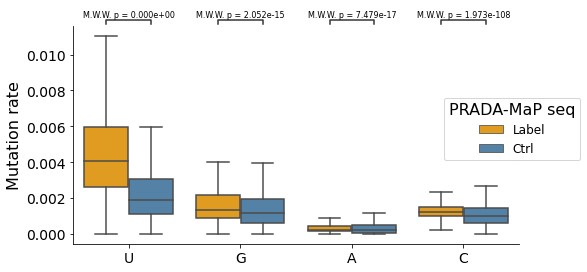

In [2]:
dir = "./Data/"
prada = pd.read_csv(dir+'PRADA_vitro_4sU_mito_NC_012920.1_profile.txt',sep='\t')

prada_label = prada[prada['Modified_effective_depth'] >=5000]
print(prada.shape)
print(prada_label.shape)
prada_label = prada_label[['Nucleotide','Sequence','Modified_rate']]
prada_label.columns=['Nucleotide','Sequence','mod_rate']
prada_label['group'] = 'Label'

prada_ctrl = prada[prada['Untreated_effective_depth'] >=5000]
print(prada.shape)
print(prada_ctrl.shape)
prada_ctrl = prada_ctrl[['Nucleotide','Sequence','Untreated_rate']]
prada_ctrl.columns=['Nucleotide','Sequence','mod_rate']
prada_ctrl['group'] = 'Ctrl'

prada_flt = pd.concat([prada_label,prada_ctrl])
dplot = prada_flt

dplot.to_csv('./Data/'+'source_data_Efig4k.csv',sep=',')

### plots ---

plt.figure(figsize=(8,4))

order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}
ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     #palette = my_pal

plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='PRADA-MaP seq',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)  #line_offset_to_box=-0.001,

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig6a_PRADA_RNA_mutation_rate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [3]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']])

                mod_rate
Sequence group          
A        Ctrl   0.003061
         Label  0.003073
C        Ctrl   0.002086
         Label  0.002847
G        Ctrl   0.004582
         Label  0.004588
N        Ctrl   0.005190
         Label  0.013010
U        Ctrl   0.002795
         Label  0.005123


In [4]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl         4562      4562
         Label        4967      4967
C        Ctrl         4714      4714
         Label        5006      5006
G        Ctrl         1957      1957
         Label        2110      2110
N        Ctrl            1         1
         Label           1         1
U        Ctrl         3697      3697
         Label        3982      3982
